In [ ]:
# NOTE: Portions of code in this notebook reference the notebook from Dr. Juan Orduz:
# https://github.com/pymc-labs/pymc-marketing/blob/main/docs/source/notebooks/mmm/mmm_multidimensional_example.ipynb

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import seaborn as sns
from matplotlib import pyplot as plt
from pymc_marketing.mmm.multidimensional import MMM
from pymc_extras.prior import Prior
from pymc_marketing.special_priors import LogNormalPrior, LaplacePrior
from pymc_marketing.mmm import LogisticSaturation, GeometricAdstock
from pymc_marketing.mmm.evaluation import compute_summary_metrics

pd.options.display.float_format = '{:,.5f}'.format

In [2]:
seed = 69 # 1312
rng = np.random.default_rng(seed)

filename = 'data/ex.csv'
try:
    df = pd.read_csv(filename, parse_dates=['date'])
except FileNotFoundError:
    print(f'Could not locate data file with filename {filename}. Check file path')
print(f'The shape of the dataset is: {df.shape}')
display(df.head())
print(df.info())

x_train = df.drop(columns=['y'])
y_train = df['y']

The shape of the dataset is: (318, 7)


,date,geo,x1,x2,event_1,event_2,y
0,2022-06-06,geo_a,"5,527.64008",0.00000,0,0,"2,647.59636"
1,2022-06-06,geo_b,"8,849.25750","8,063.91839",0,0,682.40628
2,2022-06-13,geo_a,"6,692.65569",0.00000,0,0,"5,020.82391"
3,2022-06-13,geo_b,"9,073.81799","9,354.01458",0,0,"3,753.10490"
4,2022-06-20,geo_a,"7,124.01673",0.00000,0,0,"6,184.32213"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318 entries, 0 to 317
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     318 non-null    datetime64[ns]
 1   geo      318 non-null    object        
 2   x1       318 non-null    float64       
 3   x2       318 non-null    float64       
 4   event_1  318 non-null    int64         
 5   event_2  318 non-null    int64         
 6   y        318 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(1)
memory usage: 17.5+ KB
None


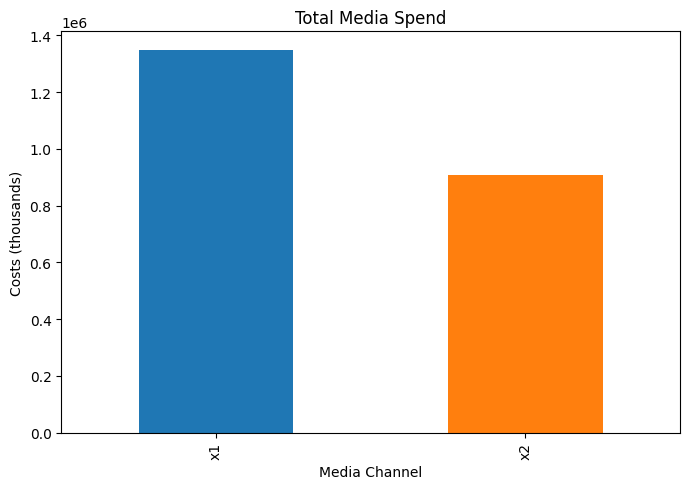

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
df[["x1", "x2"]].sum().plot(kind="bar", color=["C0", "C1"], ax=ax)
ax.set(title="Total Media Spend", xlabel="Media Channel", ylabel="Costs (thousands)")
plt.tight_layout()

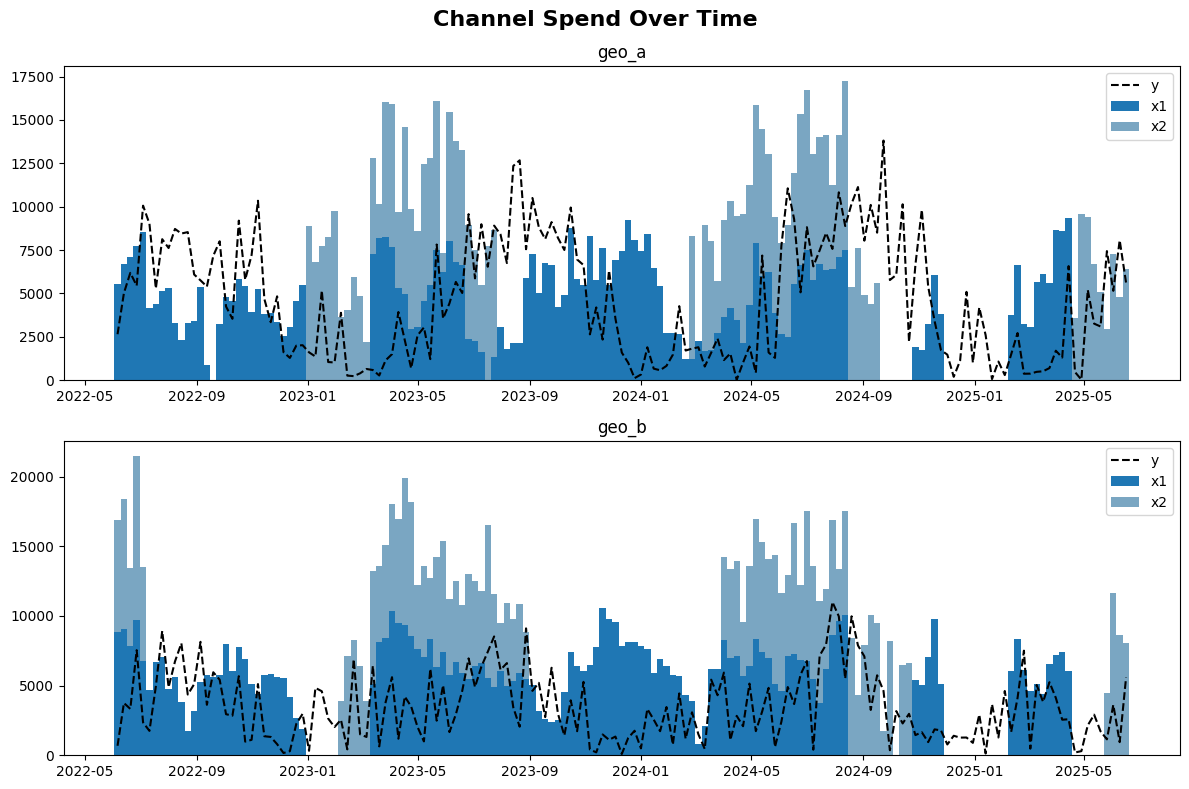

In [ ]:
# Plot channel spend over time


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
fig.suptitle("Channel Spend Over Time", fontsize=16, fontweight="bold")

blue_colors = ["#1f77b4", "#7aa6c2"]

# Plot for geo_0
geo_0_data = df[df["geo"] == "geo_a"]
ax1.bar(geo_0_data["date"], geo_0_data["x1"], label="x1", width=7, color=blue_colors[0])
ax1.bar(
    geo_0_data["date"],
    geo_0_data["x2"],
    bottom=geo_0_data["x1"],
    label="x2",
    width=7,
    color=blue_colors[1],
)
ax1.plot(geo_0_data["date"], geo_0_data["y"], "--", label="y", color="black")
ax1.set_title("geo_a")
ax1.legend()

# Plot for geo_1
geo_1_data = df[df["geo"] == "geo_b"]
ax2.bar(geo_1_data["date"], geo_1_data["x1"], label="x1", width=7, color=blue_colors[0])
ax2.bar(
    geo_1_data["date"],
    geo_1_data["x2"],
    bottom=geo_1_data["x1"],
    label="x2",
    width=7,
    color=blue_colors[1],
)
ax2.plot(geo_1_data["date"], geo_1_data["y"], "--", label="y", color="black")
ax2.set_title("geo_b")
ax2.legend()

plt.tight_layout()
plt.show()

In [129]:
# Saturation curve transformation / Adstock
# Note the hierarchical architecture: the hyperparams are each their own RV

beta_prior = LogNormalPrior(
    mean=Prior("Gamma", mu=0.25, sigma=0.25, dims="channel"),  # sigma 0.10, 0.5 no good
    std=Prior("Exponential", scale=0.25, dims="channel"),  # sigma 0.10, 0.5 no good
    dims=("channel", "geo"),
    centered=False,
)

lam_prior = Prior("Gamma", mu=0.5, sigma=0.5, dims="channel")  # sigma 0.25

saturation = LogisticSaturation(
    priors={
        "beta": beta_prior,
        "lam": lam_prior,
    },
)

# Adstock transformation
alpha_prior = Prior("Beta", alpha=2, beta=5, dims=("geo", "channel"))

adstock = GeometricAdstock(
    priors={"alpha": alpha_prior},
    l_max=8,  # 8 week decay
)

print(adstock.model_config)
print(saturation.model_config)

{'adstock_alpha': Prior("Beta", alpha=2, beta=5, dims=("geo", "channel"))}
{'saturation_lam': Prior("Gamma", mu=0.5, sigma=0.5, dims="channel"), 'saturation_beta': <pymc_marketing.special_priors.LogNormalPrior object at 0x132b883b0>}


In [130]:
model_config = {
    "intercept": Prior("HalfNormal", sigma=4.0, dims="geo"), # 4 is pretty good
    "gamma_control": Prior("Normal", mu=0, sigma=0.5, dims="control"),  # original sigma = 0.5, 1 seems ok
    "gamma_fourier": LaplacePrior(  # fourier for seasonality
        mu=0,
        b=Prior("HalfNormal", sigma=0.2),
        dims=("geo", "fourier_mode"),
        centered=False,
    ),
    "likelihood": Prior(
        "TruncatedNormal",
        lower=0,
        sigma=Prior("HalfNormal", sigma=5),  # original value = 1.5, 1 divergence at fitting
        dims=("date", "geo"),
    )
}

{'intercept': Prior("Normal", mu=0, sigma=2, dims="geo"),
 'likelihood': Prior("Normal", sigma=Prior("HalfNormal", sigma=2, dims="geo"), dims="geo"),
 'gamma_control': Prior("Normal", mu=0, sigma=2, dims=("geo", "control")),
 'gamma_fourier': Prior("Laplace", mu=0, b=1, dims=("geo", "fourier_mode")),
 'adstock_alpha': Prior("Beta", alpha=2, beta=5, dims=("geo", "channel")),
 'saturation_lam': Prior("Gamma", mu=0.5, sigma=0.5, dims="channel"),
 'saturation_beta': <pymc_marketing.special_priors.LogNormalPrior at 0x132b883b0>}

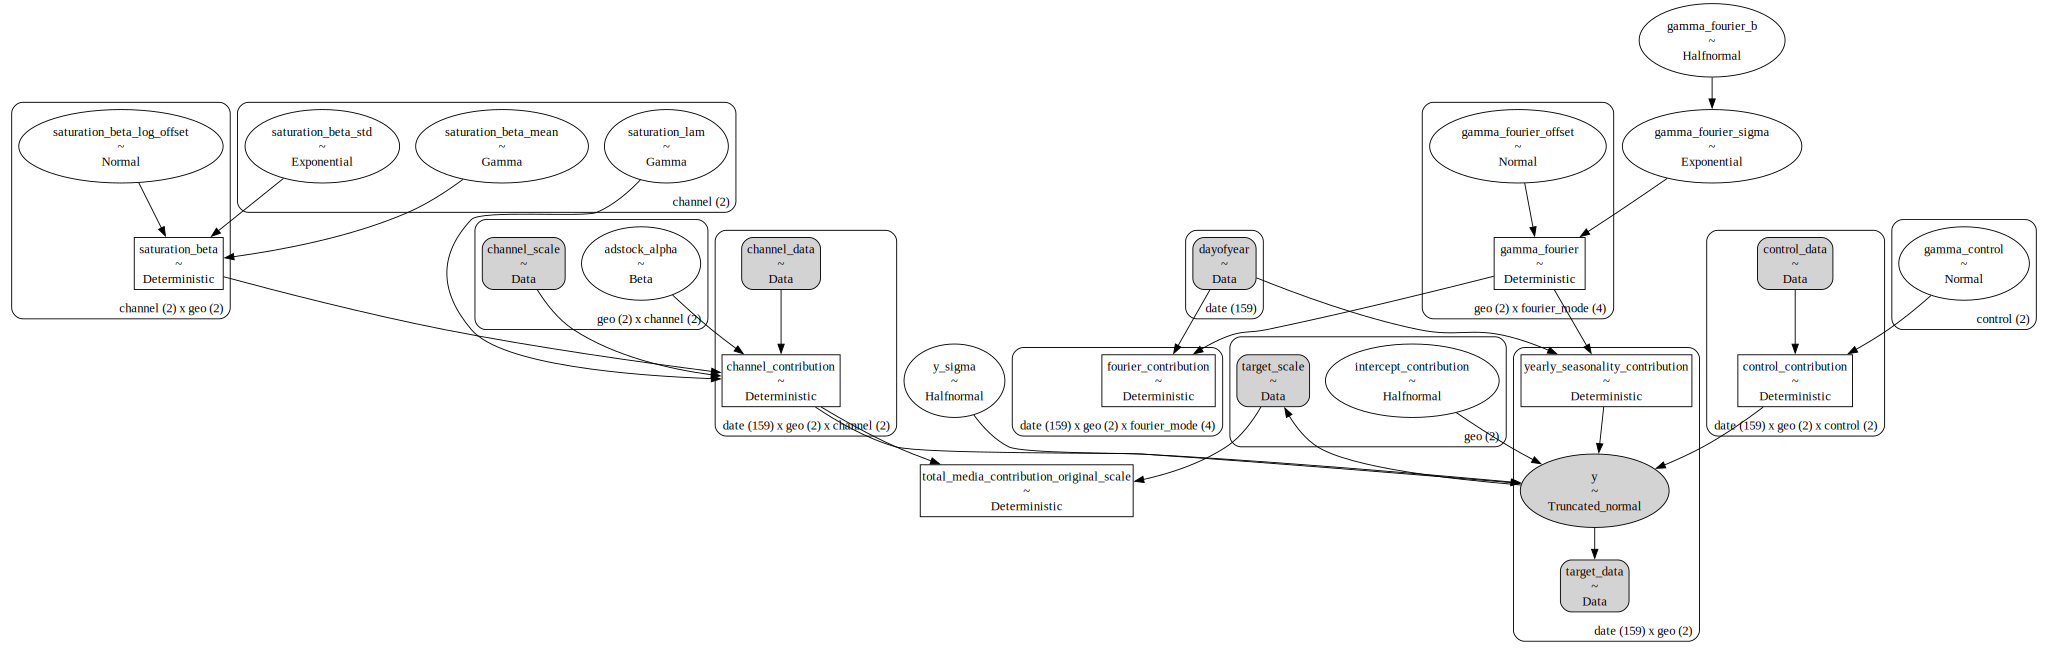

In [131]:
mmm = MMM(
    date_column="date",
    target_column="y",
    channel_columns=["x1", "x2"],
    control_columns=["event_1", "event_2"],
    dims=("geo",),
    scaling={
        "channel": {"method": "max", "dims": ()},
        "target": {"method": "max", "dims": ()},
    },
    adstock=adstock,
    saturation=saturation,
    yearly_seasonality=2,  # stable values = 1 - 10
    model_config=model_config
)

mmm.build_model(X=x_train, y=df["y"])

display(mmm.default_model_config)
mmm.model.to_graphviz()

In [19]:
mmm.table()

                             Variable  Expression                             Dimensions                           
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                      channel_scale =  Data                                   geo[2] × channel[2]                  
                       target_scale =  Data                                   geo[2]                               
                       channel_data =  Data                                   date[159] × geo[2] × channel[2]      
                        target_data =  Data                                   date[159] × geo[2]                   
                       control_data =  Data                                   date[159] × geo[2] × control[2]      
                          dayofyear =  Data                                   date[159]                            
                                                                                                                   
             intercept_contribution ~  Gamma(f(), f())                        geo[2]                               
                      adstock_alpha ~  Beta(2, 5)                             geo[2] × channel[2]                  
                     saturation_lam ~  Gamma(f(), f())                        channel[2]                           
               saturation_beta_mean ~  Gamma(f(), f())                        channel[2]                           
                saturation_beta_std ~  Exponential(0.1)                       channel[2]                           
         saturation_beta_log_offset ~  Normal(0, 1)                           channel[2] × geo[2]                  
                      gamma_control ~  Normal(0, 0.5)                         control[2]                           
                    gamma_fourier_b ~  HalfNormal(0, 0.2)                                                          
                gamma_fourier_sigma ~  Exponential(f(gamma_fourier_b))                                             
               gamma_fourier_offset ~  Normal(0, 1)                           geo[2] × fourier_mode[6]             
                            y_sigma ~  HalfNormal(0, 5)                                                            
                                                                              Parameter count = 33                 
                                                                                                                   
                    saturation_beta =  f(saturation_beta_log_offset,          channel[2] × geo[2]                  
                                       saturation_beta_mean,                                                       
                                       saturation_beta_std)                                                        
               channel_contribution =  f(saturation_lam,                      date[159] × geo[2] × channel[2]      
                                       saturation_beta_log_offset,                                                 
                                       saturation_beta_mean, adstock_alpha,                                        
                                       saturation_beta_std)                                                        
 total_media_contribution_original_s…  f(saturation_lam,                                                           
                                    =  saturation_beta_log_offset,                                                 
                                       saturation_beta_mean, adstock_alpha,                                        
                                       saturation_beta_std)                                                        
               control_contribution =  f(gamma_control)                       date[159] × geo[2] × control[2]      
                      gamma_fourier =  f(gamma_fourier_o

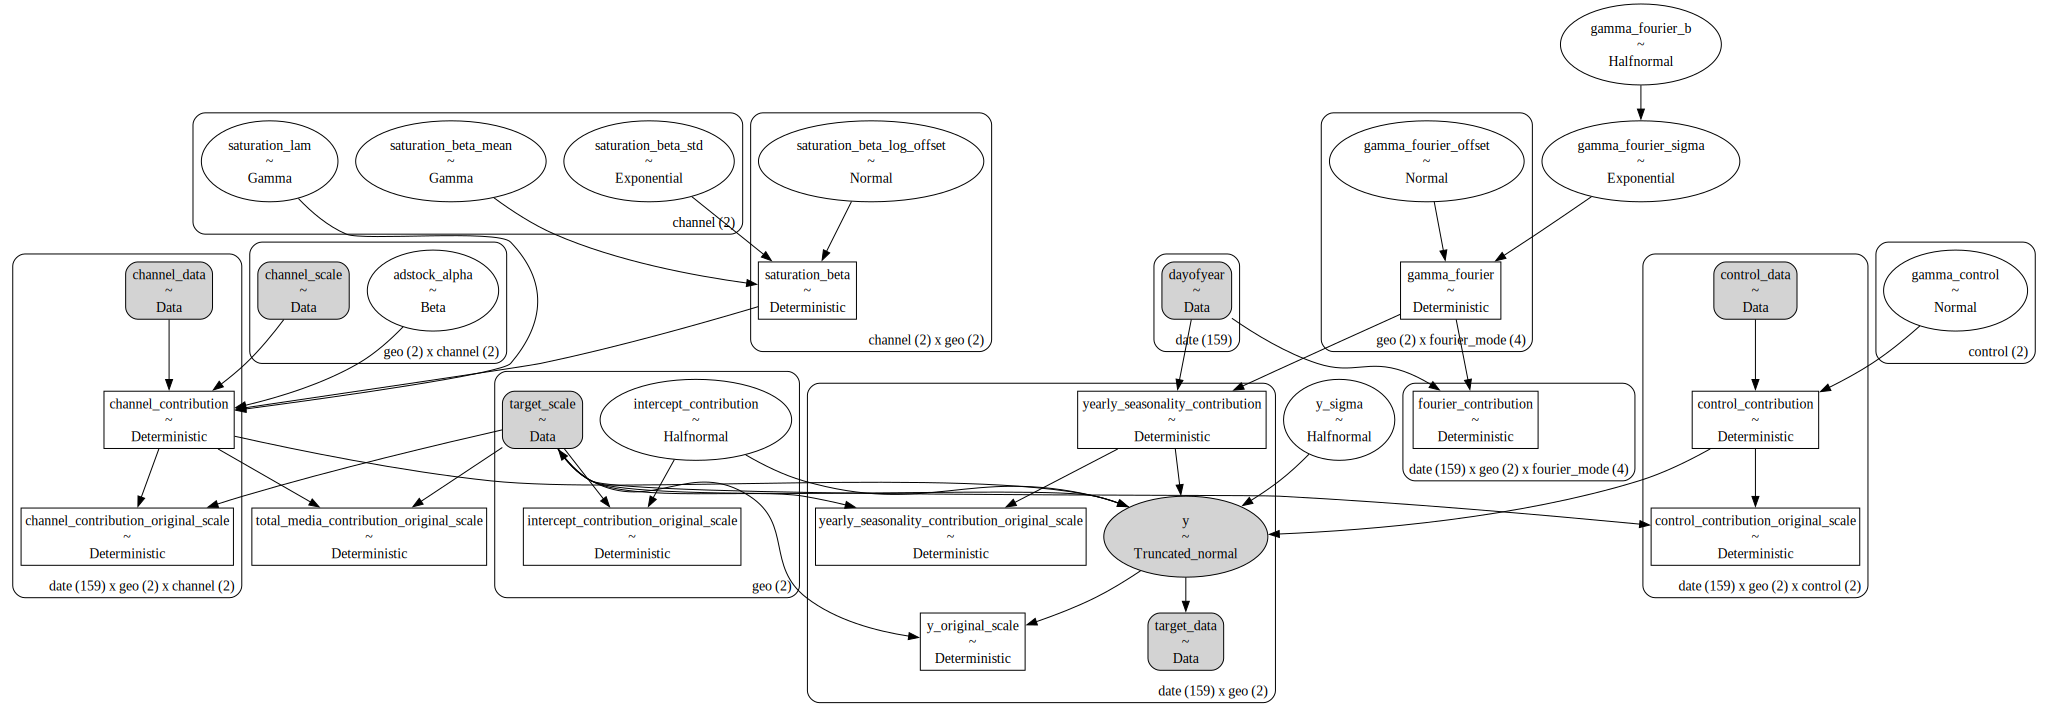

In [132]:
mmm.add_original_scale_contribution_variable(
    var=[
        "channel_contribution",
        "control_contribution",
        "intercept_contribution",
        "yearly_seasonality_contribution",
        "y",
    ]
)

pm.model_to_graphviz(mmm.model)

In [ ]:
# Use me for un-scaling parameters

scalers = mmm.get_scales_as_xarray()

scalers

{'channel_scale': <xarray.DataArray '_channel' (geo: 2, channel: 2)> Size: 32B
 array([[ 9318.97848455,  9755.9729876 ],
        [10555.0774866 , 11760.98180037]])
 Coordinates:
   * geo      (geo) object 16B 'geo_a' 'geo_b'
   * channel  (channel) object 16B 'x1' 'x2',
 'target_scale': <xarray.DataArray '_target' (geo: 2)> Size: 16B
 array([13812.08025674, 11002.97913936])
 Coordinates:
   * geo      (geo) object 16B 'geo_a' 'geo_b'}

Sampling: [adstock_alpha, gamma_control, gamma_fourier_b, gamma_fourier_offset, gamma_fourier_sigma, intercept_contribution, saturation_beta_log_offset, saturation_beta_mean, saturation_beta_std, saturation_lam, y, y_sigma]


Text(0.5, 1.03, 'Prior Predictive')

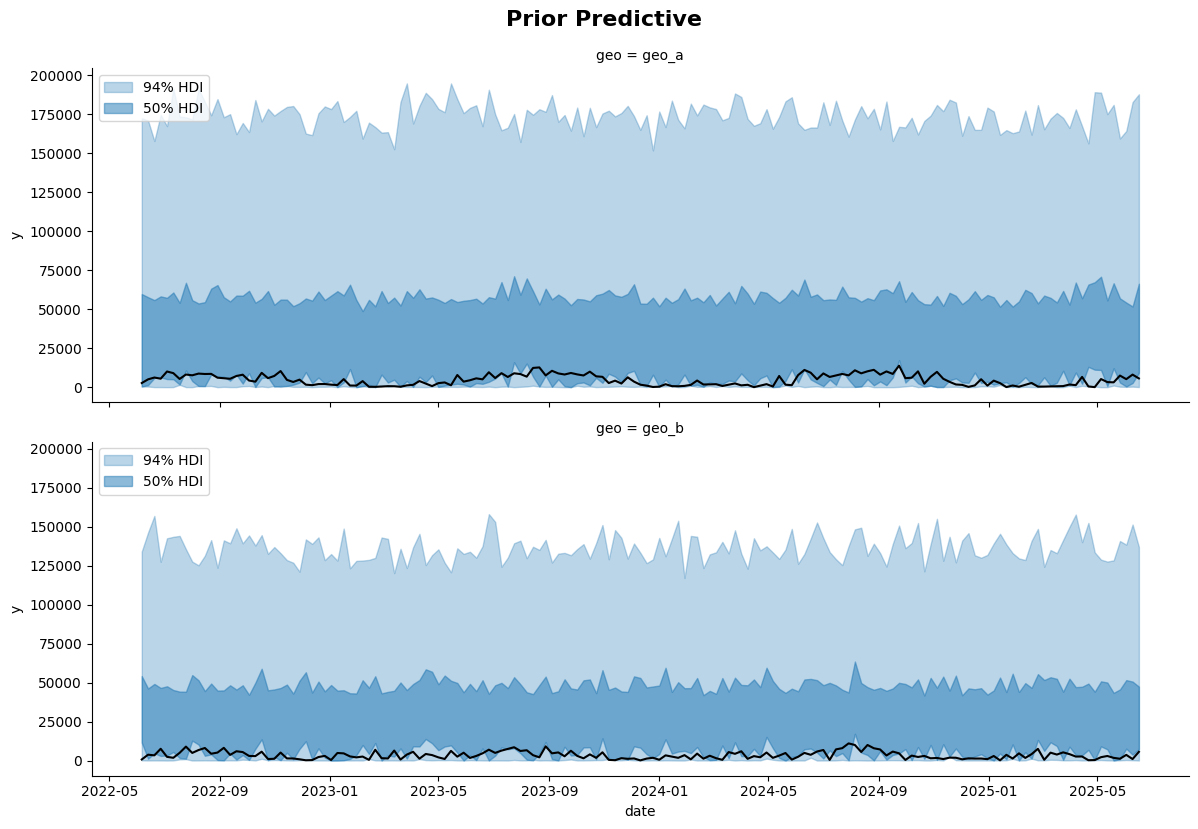

In [133]:
# plot prior predictive checks for y_original_scale, faceted by geo

with mmm.model:
    prior = pm.sample_prior_predictive()

g = sns.relplot(
    data=df,
    x="date",
    y="y",
    color="black",
    col="geo",
    col_wrap=1,
    kind="line",
    height=4,
    aspect=3,
)

axes = g.axes.flatten()

for ax, geo in zip(axes, mmm.model.coords["geo"], strict=True):
    az.plot_hdi(
        x=mmm.model.coords["date"],
        y=(
            prior.prior.sel(geo=geo)["y_original_scale"]
            .unstack()
            .transpose(..., "date")
        ),
        smooth=False,
        color="C0",
        hdi_prob=0.94,
        fill_kwargs={"alpha": 0.3, "label": "94% HDI"},
        ax=ax,
    )
    az.plot_hdi(
        x=mmm.model.coords["date"],
        y=(
            prior.prior.sel(geo=geo)["y_original_scale"]
            .unstack()
            .transpose(..., "date")
        ),
        smooth=False,
        color="C0",
        hdi_prob=0.5,
        fill_kwargs={"alpha": 0.5, "label": "50% HDI"},
        ax=ax,
    )
    ax.legend(loc="upper left")

g.figure.suptitle("Prior Predictive", fontsize=16, fontweight="bold", y=1.03)

In [134]:
mmm.fit(
    X=x_train,
    y=df["y"],
    chains=4,
    target_accept=0.95,
    random_seed=rng,
)

mmm.sample_posterior_predictive(
    X=x_train,
    random_seed=rng,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept_contribution, adstock_alpha, saturation_lam, saturation_beta_mean, saturation_beta_std, saturation_beta_log_offset, gamma_control, gamma_fourier_b, gamma_fourier_sigma, gamma_fourier_offset, y_sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 22 seconds.


Output()

Sampling: [y]


Output()

<xarray.Dataset> Size: 20MB
Dimensions:           (date: 159, geo: 2, sample: 4000)
Coordinates:
  * date              (date) datetime64[ns] 1kB 2022-06-06 ... 2025-06-16
  * geo               (geo) <U5 40B 'geo_a' 'geo_b'
  * sample            (sample) object 32kB MultiIndex
  * chain             (sample) int64 32kB 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3
  * draw              (sample) int64 32kB 0 1 2 3 4 5 ... 995 996 997 998 999
Data variables:
    y                 (date, geo, sample) float64 10MB 0.8509 0.4659 ... 0.3313
    y_original_scale  (date, geo, sample) float64 10MB 1.175e+04 ... 3.645e+03
Attributes:
    created_at:                 2026-04-15T18:32:01.913925+00:00
    arviz_version:              0.23.0
    inference_library:          pymc
    inference_library_version:  5.27.0

In [135]:
az.summary(
    mmm.idata,
    var_names=[
        "adstock_alpha",
        "gamma_control",
        "gamma_fourier",
        "intercept_contribution",
        "saturation_beta",
        "saturation_beta_mean",
        "saturation_beta_std",
        "saturation_lam",
        "y_sigma",
    ],
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"adstock_alpha[geo_a, x1]",0.28800,0.16200,0.03300,0.58900,0.00200,0.00200,"6,115.00000","2,773.00000",1.00000
"adstock_alpha[geo_a, x2]",0.30200,0.17000,0.01400,0.60500,0.00200,0.00300,"5,647.00000","2,243.00000",1.00000
"adstock_alpha[geo_b, x1]",0.26500,0.15300,0.01400,0.53600,0.00200,0.00300,"3,978.00000","1,798.00000",1.00000
"adstock_alpha[geo_b, x2]",0.28100,0.16200,0.00900,0.56700,0.00200,0.00300,"5,480.00000","2,196.00000",1.00000
gamma_control[event_1],0.31100,0.09000,0.14900,0.49000,0.00100,0.00100,"5,037.00000","2,733.00000",1.00000
gamma_control[event_2],-0.09900,0.09200,-0.27400,0.07300,0.00100,0.00200,"5,239.00000","2,920.00000",1.00000
"gamma_fourier[geo_a, sin_1]",-0.35200,0.03600,-0.42000,-0.28700,0.00100,0.00000,"3,964.00000","3,359.00000",1.00000
"gamma_fourier[geo_a, sin_2]",-0.03300,0.02900,-0.08600,0.02200,0.00000,0.00000,"5,516.00000","2,977.00000",1.00000
"gamma_fourier[geo_a, cos_1]",-0.29500,0.03500,-0.36100,-0.22800,0.00100,0.00000,"4,468.00000","3,683.00000",1.00000
"gamma_fourier[geo_a, cos_2]",0.00500,0.02900,-0.04500,0.06300,0.00000,0.00100,"5,709.00000","2,937.00000",1.00000


Text(0.5, 1.03, 'Model Trace')

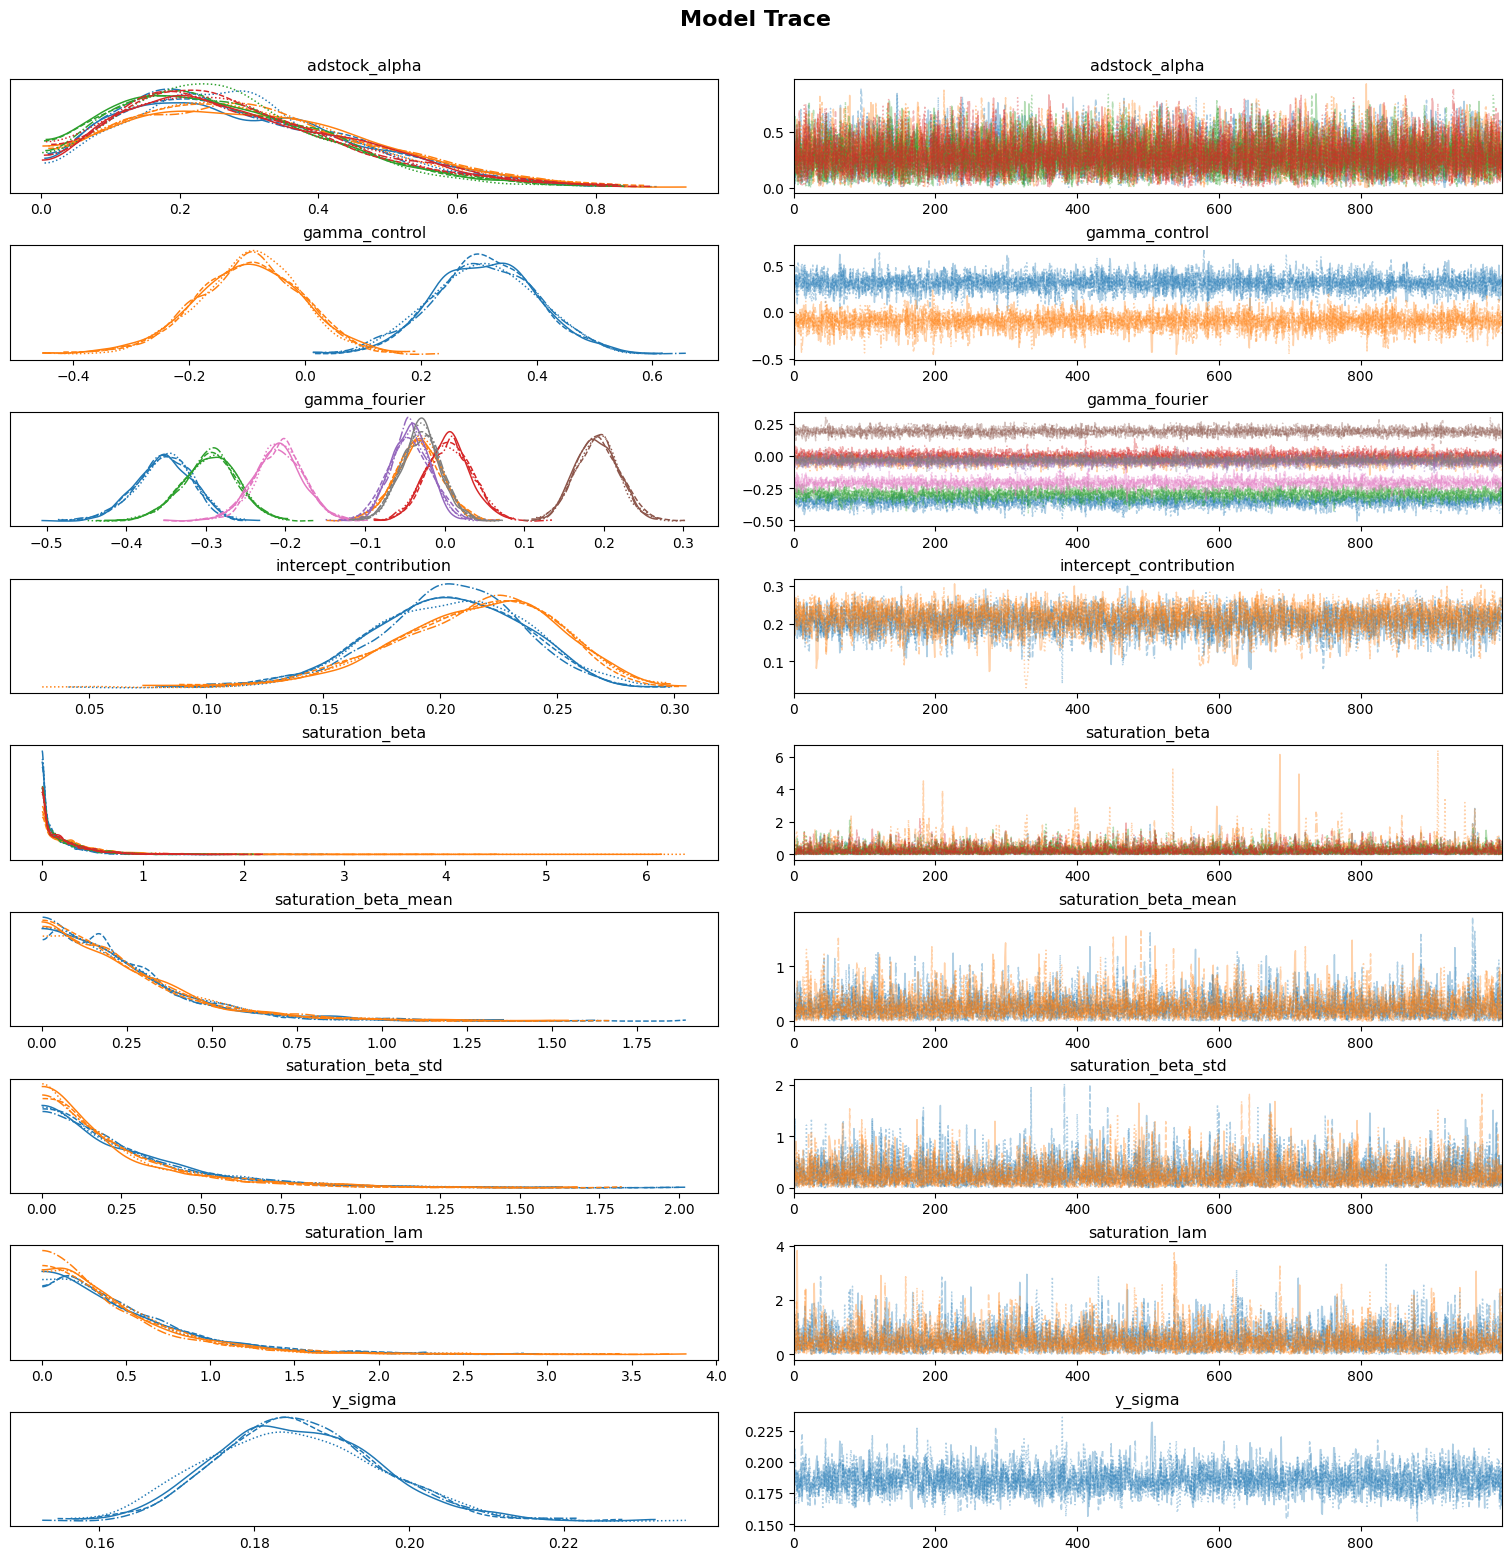

In [136]:
_ = az.plot_trace(
    data=mmm.idata,
    var_names=[
        "adstock_alpha",
        "gamma_control",
        "gamma_fourier",
        "intercept_contribution",
        "saturation_beta",
        "saturation_beta_mean",
        "saturation_beta_std",
        "saturation_lam",
        "y_sigma",
    ],
    compact=True,
    backend_kwargs={"figsize": (15, 15), "layout": "constrained"},
)
plt.gcf().suptitle("Model Trace", fontsize=16, fontweight="bold", y=1.03)

Text(0.5, 1.03, 'Posterior Predictive')

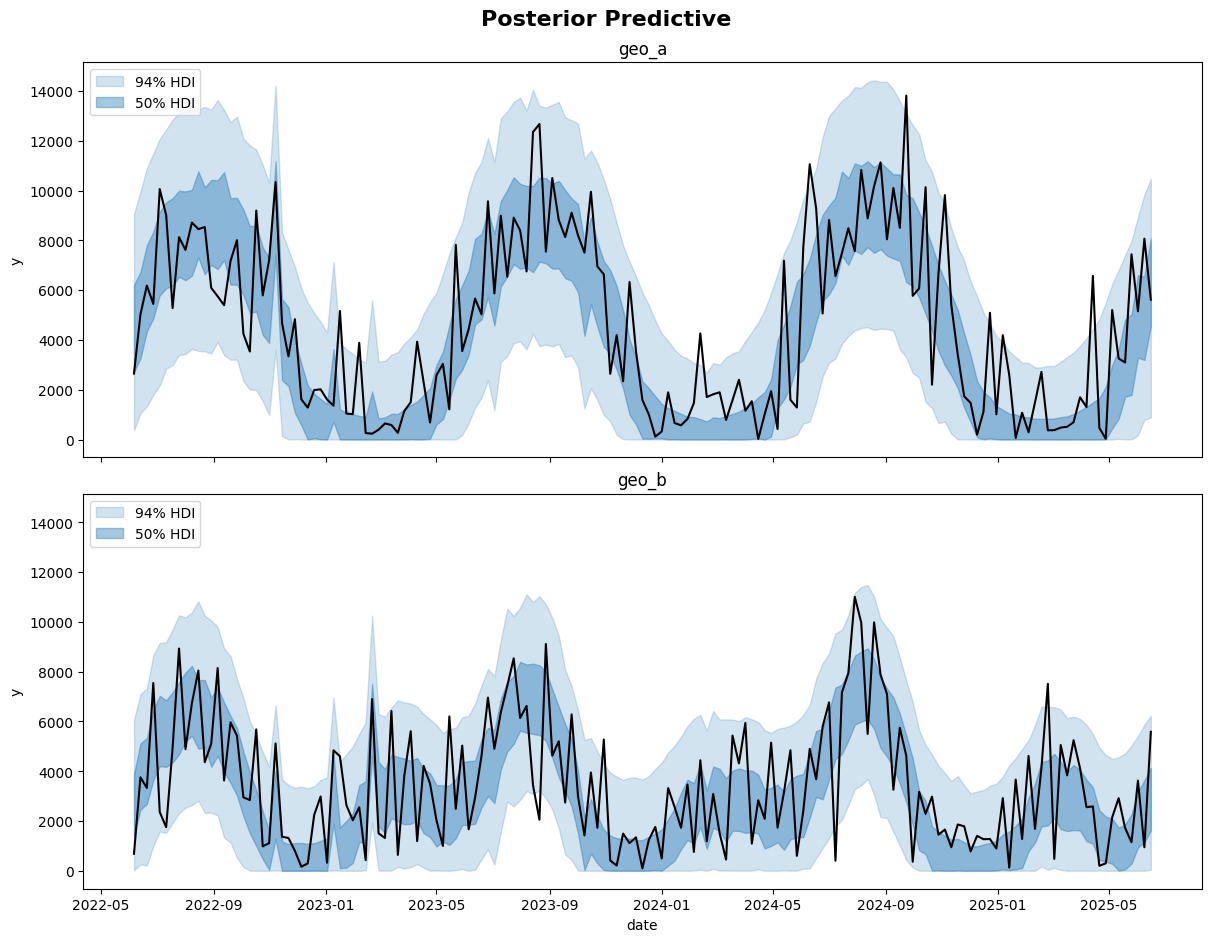

In [ ]:
# plot the posterior predictive

fig, axes = plt.subplots(
    nrows=len(mmm.model.coords["geo"]),
    figsize=(12, 9),
    sharex=True,
    sharey=True,
    layout="constrained",
)

for i, geo in enumerate(mmm.model.coords["geo"]):
    ax = axes[i]
    az.plot_hdi(
        x=mmm.model.coords["date"],
        y=(mmm.posterior_predictive.y_original_scale.sel(geo=geo)),
        color="C0",
        smooth=False,
        hdi_prob=0.94,
        fill_kwargs={"alpha": 0.2, "label": "94% HDI"},
        ax=ax,
    )

    az.plot_hdi(
        x=mmm.model.coords["date"],
        y=(mmm.idata["posterior_predictive"].y_original_scale.sel(geo=geo)),
        color="C0",
        smooth=False,
        hdi_prob=0.5,
        fill_kwargs={"alpha": 0.4, "label": "50% HDI"},
        ax=ax,
    )

    sns.lineplot(
        data=df.query("geo == @geo"),
        x="date",
        y="y",
        color="black",
        ax=ax,
    )

    ax.legend(loc="upper left")
    ax.set(title=f"{geo}")

fig.suptitle("Posterior Predictive", fontsize=16, fontweight="bold", y=1.03)

In [137]:
# get summary metrics; Note we are using the loaded model here; we are also averaging the posterior
# predictive samples to get a point estimate for the predictions; this is lazy but it works for now
# Note that we have no distributions, so the HDI values will be the same as the mean predictions;

def get_summary_metrics(mmm):
    y_pred_mean = mmm.posterior_predictive.y_original_scale.mean(dim=["chain", "draw"])
    y_pred_flattened = y_pred_mean.to_numpy().reshape(-1, 1)

    results = compute_summary_metrics(
        y_true=mmm.y,
        y_pred=y_pred_flattened,
        metrics_to_calculate=[
            'r_squared',
            'rmse',
            'nrmse',
            'mae',
            'nmae',
            'mape',
        ],
        hdi_prob=0.95,
    )

    for metric, stats in results.items():
        print(f'{metric.upper()}: {stats["mean"]:.4f}')


get_summary_metrics(mmm)

R_SQUARED: 0.6454
RMSE: 1795.7513
NRMSE: 0.1302
MAE: 1405.4664
NMAE: 0.1019
MAPE: 1.5961


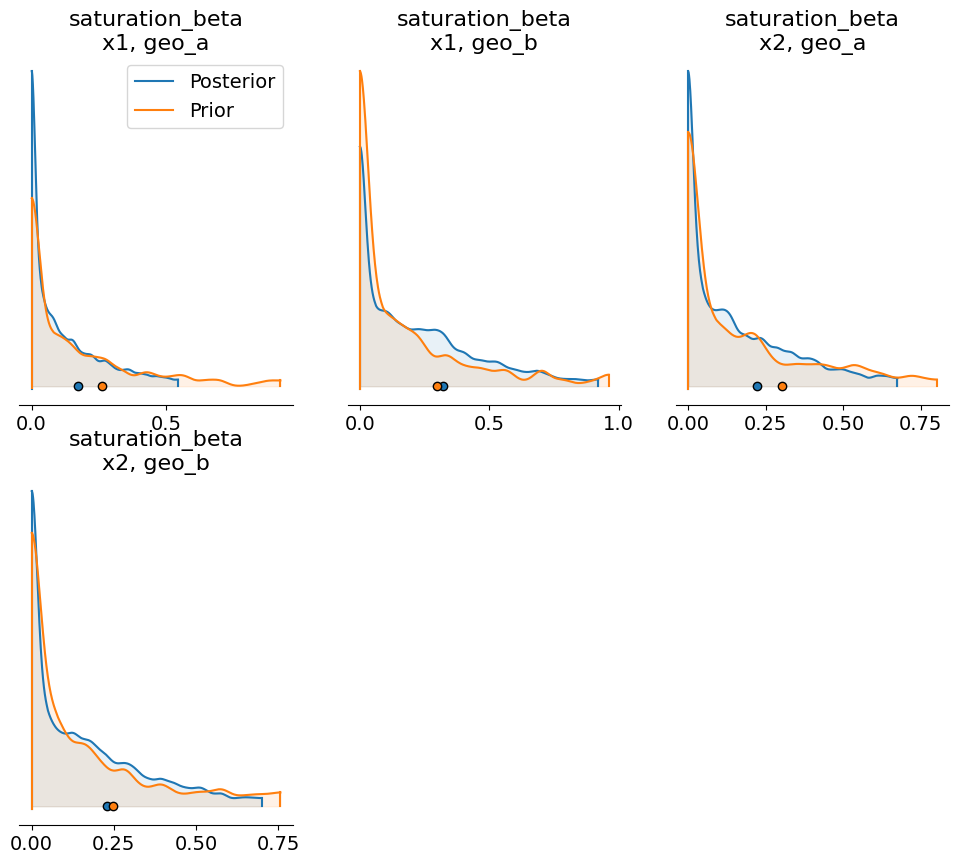

In [ ]:
# channel saturation plots by geo

axes = az.plot_density(
    [mmm.posterior, prior.prior],
    data_labels=["Posterior", "Prior"],
    var_names=["saturation_beta"],
    shade=0.1,
    figsize=(12, 10)
)

plt.show()

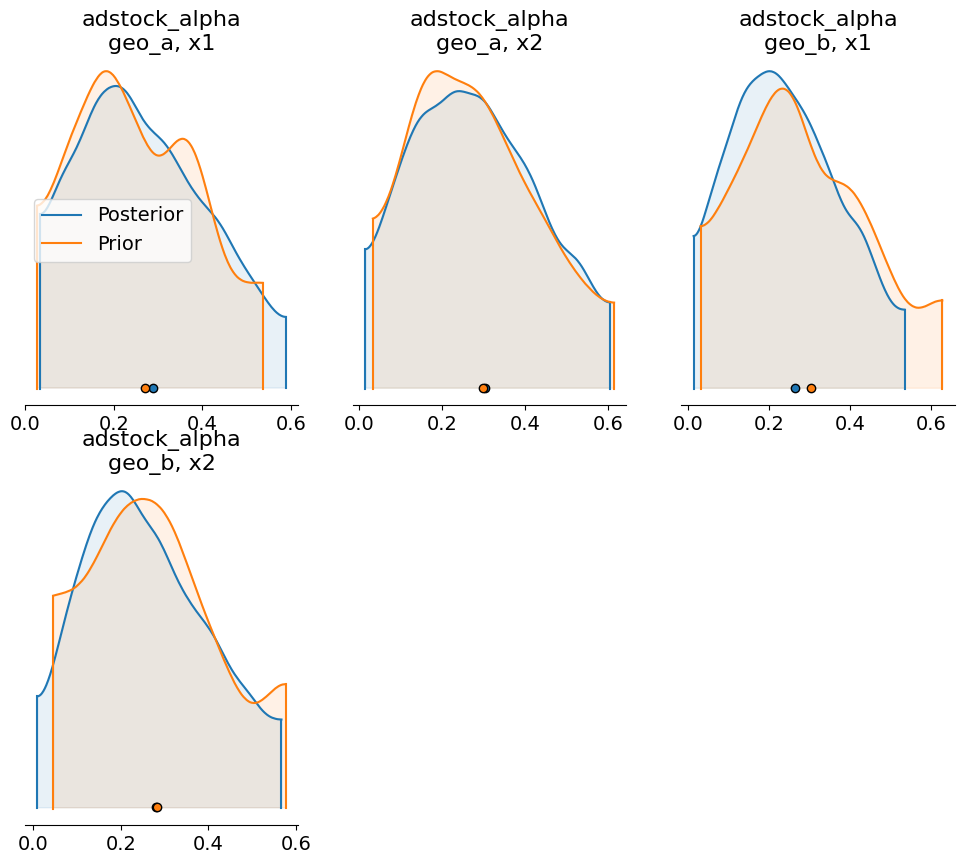

In [141]:
axes = az.plot_density(
    [mmm.posterior, prior.prior],
    data_labels=["Posterior", "Prior"],
    var_names=["adstock_alpha"],
    shade=0.1,
    figsize=(12, 10)
)

plt.show()

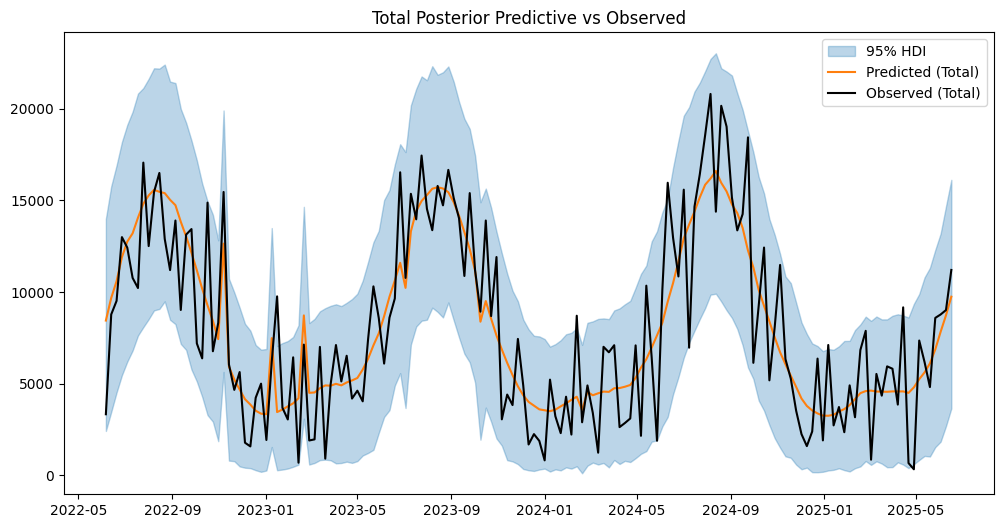

In [142]:
# posterior fit: predicted vs observed
# predictions are flattened across all geos

observed_total = df.groupby("date")["y"].sum()

post_pred_total = mmm.posterior_predictive["y_original_scale"].sum(dim="geo")

mean_prediction = post_pred_total.mean(dim=["chain", "draw"])
hdi_prediction = az.hdi(post_pred_total, hdi_prob=0.95)["y_original_scale"]

fig, ax = plt.subplots(figsize=(12, 6))

ax.fill_between(
    mean_prediction.date,
    hdi_prediction.sel(hdi="lower"),
    hdi_prediction.sel(hdi="higher"),
    alpha=0.3, color="C0", label="95% HDI"
)

ax.plot(mean_prediction.date, mean_prediction, color="C1", label="Predicted (Total)")

ax.plot(observed_total.index, observed_total.values, color="black", label="Observed (Total)")

ax.set_title("Total Posterior Predictive vs Observed")
ax.legend()
plt.show()

(<Figure size 1400x700 with 1 Axes>,
 <Axes: title={'center': 'Response Decomposition Waterfall by Components'}, xlabel='Cumulative Contribution', ylabel='Components'>)

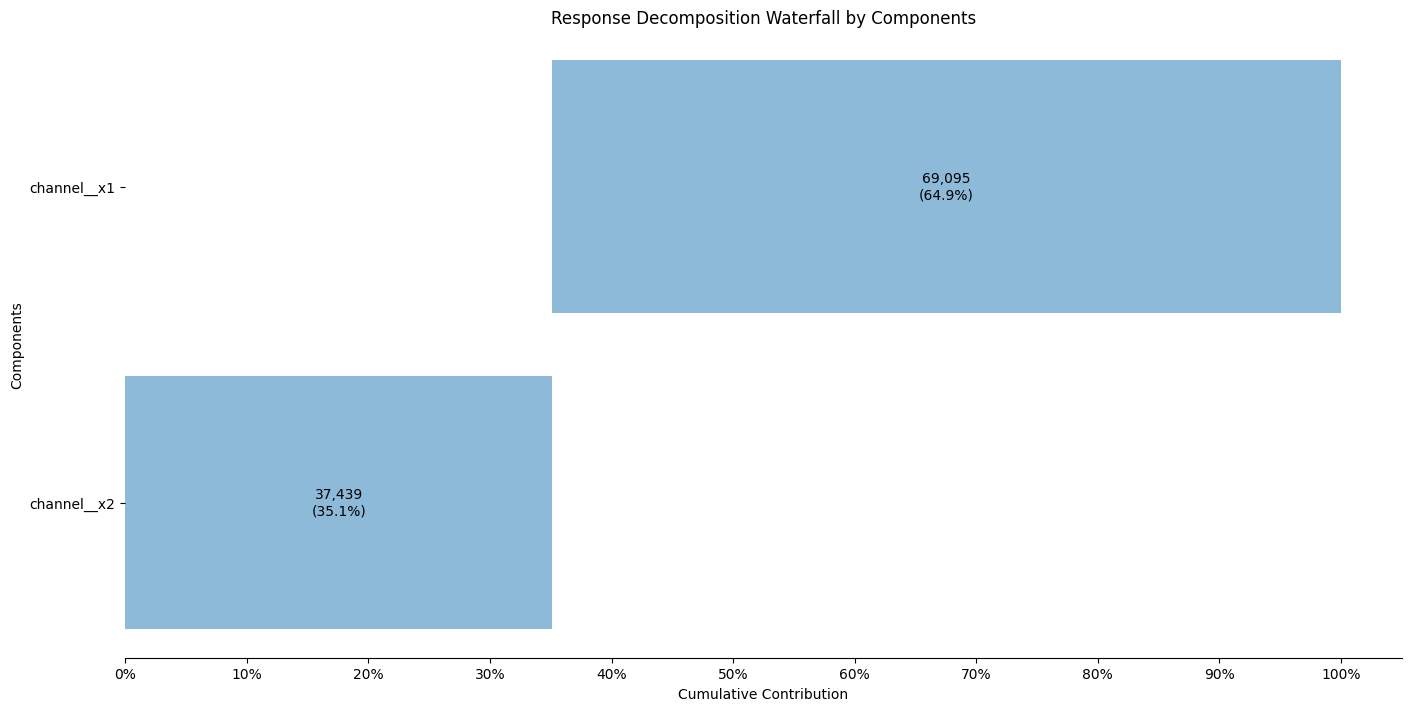

In [ ]:
# predicted channel contributions towards sales

mmm.plot.waterfall_components_decomposition(var=["channel_contribution_original_scale"])

(<Figure size 1600x800 with 4 Axes>,
 array([[<Axes: title={'center': 'channel=x1, geo=geo_a'}, xlabel='Channel Data (X)', ylabel='Channel Contributions (Y)'>,
         <Axes: title={'center': 'channel=x1, geo=geo_b'}, xlabel='Channel Data (X)', ylabel='Channel Contributions (Y)'>],
        [<Axes: title={'center': 'channel=x2, geo=geo_a'}, xlabel='Channel Data (X)', ylabel='Channel Contributions (Y)'>,
         <Axes: title={'center': 'channel=x2, geo=geo_b'}, xlabel='Channel Data (X)', ylabel='Channel Contributions (Y)'>]],
       dtype=object))

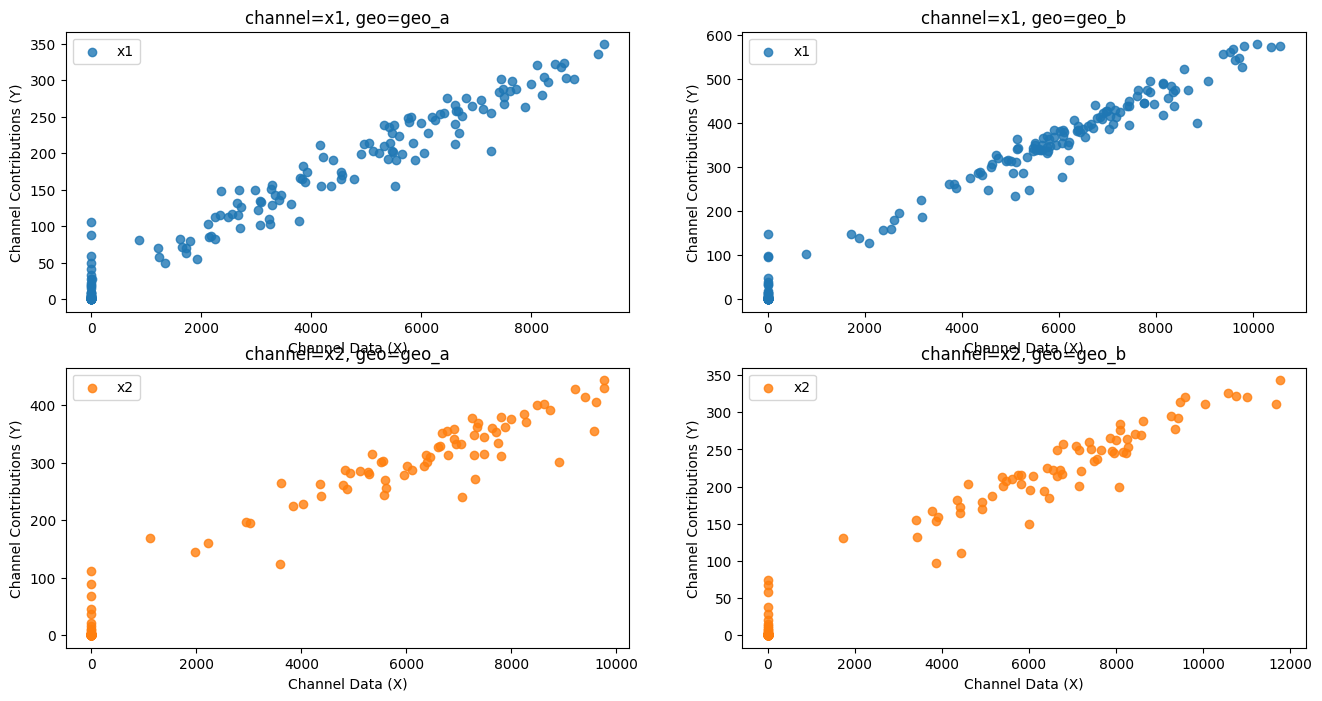

In [ ]:
# saturation plot

mmm.plot.saturation_scatterplot(width_per_col=8, height_per_row=4, original_scale=True)

Sampling: []


Output()

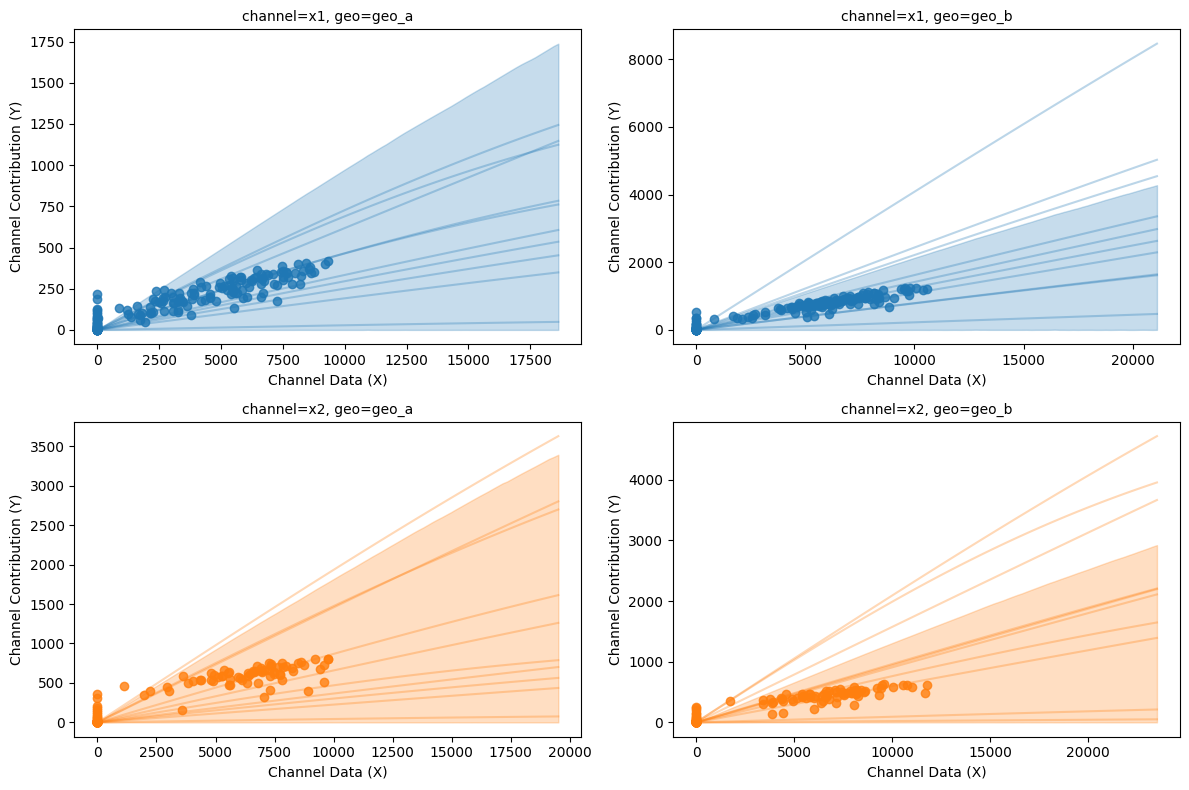

In [113]:
# saturation curve plot with uncertainty; note that the saturation curve is a transformation of the media spend,
# so we are plotting the transformed values on the y-axis and the original media spend values on the x-axis;
# this is to show how the transformation is behaving across the range of media spend values;
# we are also plotting a subset of curves from the posterior to show the uncertainty in the
# saturation curve; note that we are using the original scale for the x-axis, so we can see
# how the saturation curve behaves across the range of media spend values in their original units

curve = mmm.saturation.sample_curve(mmm.idata.posterior, max_value=2)
fig, axes = mmm.plot.saturation_curves(
    curve,
    original_scale=True,
    n_samples=10,
    hdi_probs=0.85,
    random_seed=rng,
    subplot_kwargs={"figsize": (12, 8), "ncols": 2},
    rc_params={
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
    },
)

for ax in axes.ravel():
    ax.title.set_fontsize(10)

if fig._suptitle is not None:
    fig._suptitle.set_fontsize(12)

plt.tight_layout()
plt.show()

array([<Axes: title={'center': 'x\nx1'}>,
       <Axes: title={'center': 'x\nx2'}>], dtype=object)

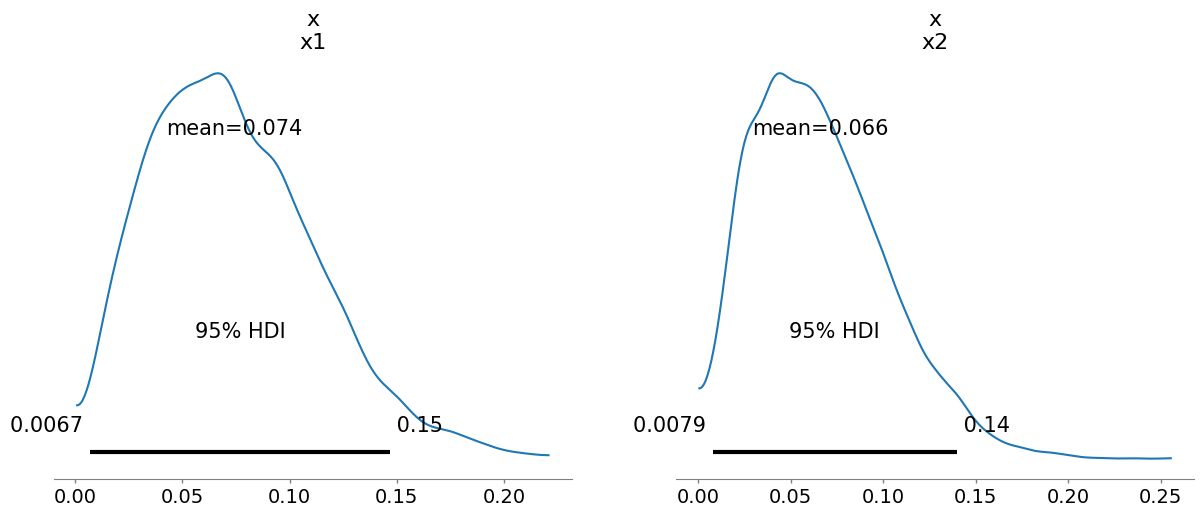

In [48]:
# channel contributions and ROAS calculation; note that we are scaling the contributions back to the original units using the target variable scale;
# this is because the contributions are in the scaled space, so we need to scale them back to the original units to get a more interpretable ROAS estimate;
# we are also summing the contributions across geos and dates to get a total contribution for each channel, which we can then divide by the total spend for each channel to get the ROAS;
# this will give us an estimate of the return on ad spend for each channel based on the model's posterior estimates of the channel contributions

import xarray as xr

# Get all scales (for target and features) as an xarray Dataset
# Extract the specific scale for your target variable 'y'
y_scale = scalers["target_scale"].values

y_scale_xr = xr.DataArray(y_scale, coords={"geo": mmm.idata.posterior.geo}, dims="geo")

# Extract channel contributions and scale them to the original units
contributions_original = mmm.idata.posterior["channel_contribution"] * y_scale_xr

# sum contributions across 'date' and 'geo' to get total impact per channel
total_impact = contributions_original.sum(dim=["date", "geo"])

channel_cols = [
        'x1',
        'x2',
        ]

total_spend = x_train[channel_cols].sum().values

roas_posterior = total_impact / total_spend

az.plot_posterior(roas_posterior, hdi_prob=0.95)

# This plot shows the distribution of ROAS for each channel, allowing you to see which channels are likely to be
# more effective in driving revenue based on the model's posterior estimates. The higher the ROAS, the better the return on ad spend for that channel.

In [64]:
az.summary(roas_posterior, hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
x[x1],0.08000,0.04400,0.00900,0.16900,0.00100,0.00100,"1,727.00000","1,375.00000",1.00000
x[x2],0.07300,0.04000,0.00400,0.15000,0.00100,0.00100,"3,431.00000","2,857.00000",1.00000


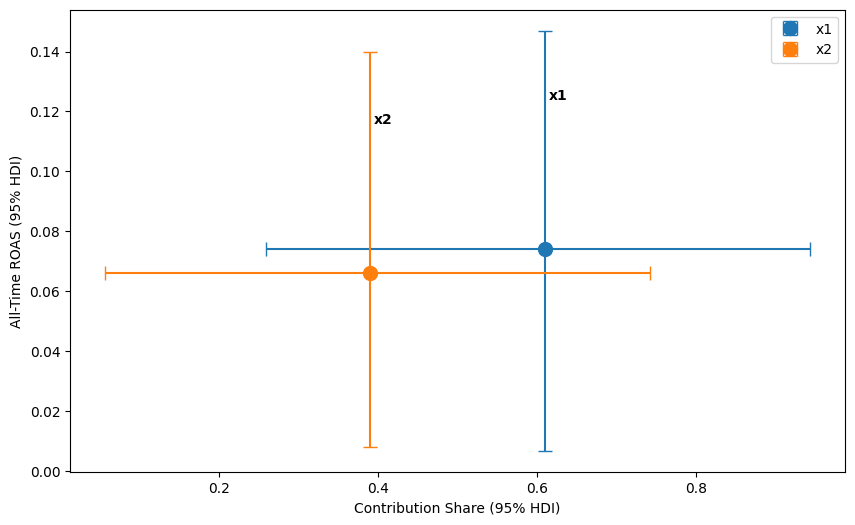

In [ ]:
'''
Horizontal Bars (Share): Show how certain you are about the "volume" impact of a channel.
Vertical Bars (ROAS): Show the uncertainty in financial efficiency. Longer vertical bars often mean the channel has high variance or less data.
Strategic Overlap: If the error bars of two channels overlap significantly, the model says their performance is statistically similar.

High ROAS / Low Share (Top Left): These channels are highly efficient but might be under-invested. These could be scaled up.
Low ROAS / High Share (Bottom Right): These are the "workhorses" that drive volume but at a lower efficiency. We might be hitting saturation here.
High ROAS / High Share (Top Right): These are the "star" channels—efficient even at high volume.
Low ROAS / Low Share (Bottom Left): These channels are not currently contributing much and are inefficient.
They might be candidates for budget cuts or re-evaluation.
'''


def get_plot_stats(data_xr):
    mean = data_xr.mean(dim=["chain", "draw"]) # data_xr dims (chain, draw, channel)
    hdi = az.hdi(data_xr, hdi_prob=0.95)
    var_name = list(hdi.data_vars)[0]
    return mean, hdi[var_name]

# Sum the original scale contributions across all 4 channels to get "Total Media Impact"
total_media_impact = total_impact.sum(dim="channel")

# Calculate the share for each channel
contribution_share = total_impact / total_media_impact

roas_mean, roas_hdi = get_plot_stats(roas_posterior)
share_mean, share_hdi = get_plot_stats(contribution_share)

fig, ax = plt.subplots(figsize=(10, 6))

for i, channel in enumerate(channel_cols):
    # .isel(channel=i) grabs the specific channel's values by position
    m_x = share_mean.isel(channel=i).values
    m_y = roas_mean.isel(channel=i).values

    # Calculate error distances
    x_err = [[m_x - share_hdi.isel(channel=i, hdi=0).values],
             [share_hdi.isel(channel=i, hdi=1).values - m_x]]

    y_err = [[m_y - roas_hdi.isel(channel=i, hdi=0).values],
             [roas_hdi.isel(channel=i, hdi=1).values - m_y]]

    ax.errorbar(
        m_x, m_y,
        xerr=x_err, yerr=y_err,
        fmt='o', markersize=10, capsize=5, label=channel
    )

    ax.text(m_x + 0.005, m_y + 0.05, channel, fontweight='bold')

ax.set_xlabel("Contribution Share (95% HDI)")
ax.set_ylabel("All-Time ROAS (95% HDI)")
ax.legend()
plt.show()


In [ ]:
# COMMENCE POSTERIOR SBC ANALYSIS

import xarray as xr

n_sims = 10

n_chains = mmm.posterior.dims["chain"]  # 4
n_draws = mmm.posterior.dims["draw"]  # 1000

indices = rng.choice(n_chains * n_draws, size=n_sims, replace=False)
chains = indices // n_draws
draws = indices % n_draws

# extract ground truth 'y' and 'contributions' for these indices
# shape of target_sims: (100, date, geo)
target_sims = mmm.posterior_predictive["y_original_scale"].isel(
    chain=xr.DataArray(chains, dims="sim"),
    draw=xr.DataArray(draws, dims="sim")
    ).values

# shape of truth_params: (100, date, geo, channel)
truth_params = mmm.posterior["channel_contribution"].isel(
    chain=xr.DataArray(chains, dims="sim"),
    draw=xr.DataArray(draws, dims="sim")
    ).values


In [ ]:
from tqdm import trange

all_ranks = []

for i in trange(n_sims):
    # we are treating the simulated 'y' as the 'truth' for each iteration of SBC
    y_sim = pd.Series(target_sims[i].flatten(), name='y')

    new_model = MMM(
        date_column="date",
        target_column="y",
        channel_columns=["x1", "x2"],
        control_columns=["event_1", "event_2"],
        dims=("geo",),
        scaling={
            "channel": {"method": "max", "dims": ()},
            "target": {"method": "max", "dims": ()},
        },
        adstock=adstock,
        saturation=saturation,
        yearly_seasonality=2,
        model_config=model_config
        )

    new_model.build_model(X=x_train, y=y_sim)

    new_model.add_original_scale_contribution_variable(
        var=[
            "y",
        ]
    )

    new_model.fit(
        X=x_train,
        y=y_sim,
        target_accept=0.95,
        random_seed=rng
        )

    new_model.sample_posterior_predictive(
        X=x_train,
        random_seed=rng,
        )

    get_summary_metrics(new_model)

    # calculate Ranks for channel_contributions
    new_post = new_model.idata.posterior["channel_contribution"].values
    truth = truth_params[i] # The truth for this specific simulation

    # rank = count how many samples are less than truth. this is the PIT step
    # aggregate across time/geo to get a single rank per channel for simplicity
    rank = (new_post < truth).mean(axis=(0, 1)) # Mean across chains, draws, time, geo
    all_ranks.append(rank)

ranks_array = np.array(all_ranks)


  0%|          | 0/10 [00:00<?, ?it/s]Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept_contribution, adstock_alpha, saturation_lam, saturation_beta_mean, saturation_beta_std, saturation_beta_log_offset, gamma_control, gamma_fourier_b, gamma_fourier_sigma, gamma_fourier_offset, y_sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 15 seconds.


Output()

Sampling: [y]


...

Output()

Sampling: [y]


Output()

100%|██████████| 10/10 [04:00<00:00, 24.06s/it]

R_SQUARED: 0.5977
RMSE: 1950.7111
NRMSE: 0.1434
MAE: 1497.9936
NMAE: 0.1102
MAPE: 1.2139


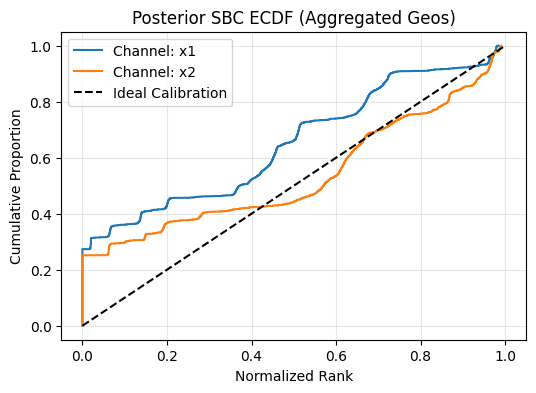

In [147]:
# ranks_array shape is (n_sims, n_geos, n_channels), (100, 2, 2) or (5, 2, 2)

plt.figure(figsize=(6, 4))

for c, channel_name in enumerate(mmm.channel_columns):

    # extract ranks for this channel across ALL sims and ALL geos
    # This turns (100, 2) into (200,)
    channel_ranks = ranks_array[:, :, c].flatten()

    # sort them to create the ECDF
    sorted_ranks = np.sort(channel_ranks)

    # create the y-axis (cumulative proportion) the number of points is now n_sims * n_geos
    n_points = len(sorted_ranks)
    y_values = np.arange(1, n_points + 1) / n_points

    plt.step(sorted_ranks, y_values, label=f"Channel: {channel_name}", where='post')

plt.plot([0, 1], [0, 1], color="black", linestyle="--", label="Ideal Calibration") # 'ideal' diagonal line

plt.xlabel("Normalized Rank")
plt.ylabel("Cumulative Proportion")
plt.title("Posterior SBC ECDF (Aggregated Geos)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [29]:
mmm.model_config

{'intercept': Prior("Gamma", mu=0.1, sigma=0.5, dims="geo"),
 'likelihood': Prior("TruncatedNormal", lower=0, sigma=Prior("HalfNormal", sigma=5), dims=("date", "geo")),
 'gamma_control': Prior("Normal", mu=0, sigma=0.5, dims="control"),
 'gamma_fourier': <pymc_marketing.special_priors.LaplacePrior at 0x11c50da90>,
 'adstock_alpha': Prior("Beta", alpha=2, beta=5, dims=("geo", "channel")),
 'saturation_lam': Prior("Gamma", mu=0.5, sigma=0.25, dims="channel"),
 'saturation_beta': <pymc_marketing.special_priors.LogNormalPrior at 0x120a42f90>}